# SVM - Part 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from cvxopt import matrix, solvers
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('dataset/GENDER_CLASSIFICATION.csv')
df.head()

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,gt
0,-0.900846,0.102587,-0.397814,0.112796,2.588096,-0.192754,-0.968311,-0.490886,-0.872099,-0.288411,...,2.541431,1.739102,0.166066,4.584869,-0.107031,-0.913990,-0.686416,-0.368085,-0.870545,0
1,-0.838868,0.039976,-0.387101,0.055413,2.066874,-0.226948,-0.947416,-0.472817,-0.855387,-0.207101,...,1.991721,1.259745,0.065058,3.019790,-0.110633,-0.890023,-0.611625,-0.298235,-0.855208,0
2,-0.814961,-0.010184,-0.397147,0.092713,1.897454,-0.269387,-0.945285,-0.449579,-0.849705,-0.151179,...,1.822978,1.105511,0.065353,2.500681,-0.052730,-0.885691,-0.583346,-0.218140,-0.856456,0
3,-0.110470,0.027849,-0.044310,-0.005343,0.177831,-0.232092,-0.562700,-0.400713,-0.552356,0.037349,...,-0.098367,-0.370318,-0.123008,-0.861314,0.106840,-0.483669,-0.224164,0.147321,-0.615051,0
4,-0.626313,-0.091985,-0.373756,-0.005083,1.172486,-0.314868,-0.885046,-0.412587,-0.818729,-0.012022,...,1.030348,0.421886,-0.068029,0.258984,-0.057158,-0.834079,-0.441066,-0.099874,-0.829539,0


General SVM class, contains the fit method using matrix and solvere (requested in part 1) and the svo and mvp method (requested in part 2)

In [2]:
class SVM:
    def __init__(self, C=1.0, kernel='Gaussian', gamma=1, p=3,
                 tol=1e-6):
        # hyperparams
        self.C = float(C)
        self.kernel_type = kernel 
        self.gamma = gamma    
        self.p = p
        self.tol = tol

        # learned attributes
        self.alphas = None        # all alpha (length n)
        self.support_ = None      # indices of support vectors
        self.X_sv = None
        self.y_sv = None
        self.alpha_sv = None      # alphas corresponding to sv
        self.b = 0.0

        # preprocessing
        self.scaler = None
        # mapping labels -> {-1, +1}
        self.label_map = None
        self.inv_label_map = None



    def kernel(self, X1, X2=None):
            
            if X2 is None:
                X2 = X1

            if self.kernel_type == "Gaussian":
                # Compute squared norms
                X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
                X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
                # Pairwise squared distance
                dist_sq = X1_sq + X2_sq - 2 * X1 @ X2.T
                # Gaussian kernel
                K = np.exp(-self.gamma * dist_sq)
                return K

            elif self.kernel_type == "Polynomial":
                K = (X1 @ X2.T + 1)**self.p
                return K
            

    def encode_labels(self, y):
        uniq = np.unique(y)
        if uniq.shape[0] != 2:
            raise ValueError("This implementation supports only binary classification.")
        # map unique[0] -> -1, unique[1] -> +1
        self.label_map = {uniq[0]: -1, uniq[1]: 1}
        self.inv_label_map = {-1: uniq[0], 1: uniq[1]}
        y_mapped = np.array([self.label_map[yy] for yy in y], dtype=float)
        return y_mapped
    
    
    def fit(self, X, y):
        """
        X: (n_samples, n_features) numpy array
        y: array-like labels (two classes)
        """
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()

        # encode labels to -1 / +1
        y = self.encode_labels(y_in)

        # scaling
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)

        n_samples = Xs.shape[0]

        # compute full kernel matrix
        K = self.kernel(Xs)    # (n_samples, n_samples)

        # Build Q = (y y^T) * K
        Y = y.reshape(-1, 1)
        Q = (Y @ Y.T) * K  # elementwise multiply
        # numerical stabilizer: symmetrize & add tiny jitter
        # Q = 0.5 * (Q + Q.T) + 1e-12 * np.eye(n_samples)

        P = matrix(Q)                         # cvxopt matrix
        q = matrix(-np.ones((n_samples, 1)))  # minimize 1/2 a^T P a + q^T a -> q = -1

        # G and h for 0 <= alpha <= C
        G_std = np.vstack((-np.eye(n_samples), np.eye(n_samples)))
        h_std = np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C))
        G = matrix(G_std)
        h = matrix(h_std)

        # equality A y = 0  (sum alpha_i y_i = 0)
        A = matrix(y.reshape(1, -1))
        b = matrix(0.0)

        sol = solvers.qp(P, q, G, h, A, b)

        # extract alphas (as numpy array)
        alphas_all = np.array(sol['x']).reshape(-1)

        # keep full alphas array for diagnostics
        self.alphas = alphas_all.copy()

        # support vectors: alpha > tol
        sv_mask = alphas_all > self.tol
        sv_indices = np.where(sv_mask)[0]
        self.support_ = sv_indices
        self.X_sv = Xs[sv_mask]
        self.y_sv = y[sv_mask]
        self.alpha_sv = alphas_all[sv_mask]

        # compute bias b: average over alphas with 0 < alpha < C (free SV)
        free_sv_mask = (alphas_all > self.tol) & (alphas_all < self.C - self.tol)
        free_indices = np.where(free_sv_mask)[0]

        if free_indices.size > 0:
            b_vals = []
            for i in free_indices:
                # f(x_i) = sum_j alpha_j y_j K(x_j, x_i)
                f_i = np.sum(alphas_all * y * K[:, i])
                b_vals.append(y[i] - f_i)
            self.b = np.mean(b_vals)
        else:
            # fallback: average over all support vectors
            b_vals = []
            for idx in sv_indices:
                f_i = np.sum(alphas_all * y * K[:, idx])
                b_vals.append(y[idx] - f_i)
            self.b = np.mean(b_vals)

        # keep training-data-size alphas if needed (self.alphas already)
        return self
    

    def decision_function(self, X):
        """Return raw decision scores (float), using only SV."""
        X = np.asarray(X, dtype=float)
        Xs = self.scaler.transform(X)
        K = self.kernel(Xs, self.X_sv)  # shape (m, n_sv)
        # weights = alpha_sv * y_sv (elementwise)
        weights = self.alpha_sv * self.y_sv
        scores = K @ weights + self.b    # shape (m,)
        return np.asarray(scores).reshape(-1)

    def predict(self, X):
        scores = self.decision_function(X)
        preds = np.where(scores >= 0, 1, -1)
        # map back to original labels
        return np.array([self.inv_label_map[int(p)] for p in preds])
    
    def score(self, X, y):
        y = np.asarray(y) 
        y_pred = self.predict(X)
        return np.mean(y_pred == y)
    

    def get_support(self):
        return self.support_
    
    def fit_smo(self, X, y, tol=1e-3, max_passes=10, max_iter=10):
        X = np.asarray(X, dtype=float)
        y_in = np.asarray(y).ravel()
        y_enc = self.encode_labels(y_in)
        self.scaler = StandardScaler().fit(X)
        Xs = self.scaler.transform(X)
        n = y_enc.shape[0]
        alphas = np.zeros(n)
        b = 0.0
        passes = 0
        iteration = 0
        K = self.kernel(Xs)

        def f(i):
            return np.sum(alphas * y_enc * K[:, i]) + b

        # Inizializza E in modo incrementale
        E = np.array([f(i) - y_enc[i] for i in range(n)])

        while passes < max_passes and iteration < max_iter:
            print(f"\n--- Iteration {iteration + 1}, consecutive passes without updates: {passes} ---")
            num_changed = 0
            tested_pairs = np.zeros((n, n), dtype=bool)  # Uso di una matrice booleana per il controllo

            for i in range(n):
                ei = E[i]
                ai = alphas[i]
                yi = y_enc[i]

                # Controllo KKT
                kkt_violation = ((ai < self.C and yi * ei < -tol) or (ai > 0 and yi * ei > tol))
                if not kkt_violation:
                    continue

                # Seleziona il secondo esempio in modo più efficiente
                candidates = np.where(np.abs(E - ei) > 1e-3)[0]  # Seleziona solo quelli con errore significativo
                candidates = candidates[candidates != i]  # Escludi il punto corrente

                if len(candidates) == 0:
                    continue

                j = np.argmax(np.abs(E[candidates] - ei))  # Seleziona il punto con l'errore maggiore

                # Se la coppia è già stata testata, salta
                if tested_pairs[i, j]:
                    continue
                tested_pairs[i, j] = True
                tested_pairs[j, i] = True  # Per evitare di testare di nuovo la stessa coppia (simmetria)

                aj = alphas[j]
                yj = y_enc[j]
                ej = E[j]

                # Calcola i limiti L e H
                if yi != yj:
                    L = max(0, aj - ai)
                    H = min(self.C, self.C + aj - ai)
                else:
                    L = max(0, ai + aj - self.C)
                    H = min(self.C, ai + aj)

                if L == H:
                    continue

                eta = 2 * K[i, j] - K[i, i] - K[j, j]
                if eta >= 0:
                    continue

                old_aj = aj
                alphas[j] -= yj * (ei - ej) / eta
                alphas[j] = np.clip(alphas[j], L, H)

                if abs(alphas[j] - old_aj) < 1e-5:
                    continue

                alphas[i] += yi * yj * (old_aj - alphas[j])

                # Aggiorna il bias b
                b1 = b - ei - yi * (alphas[i] - ai) * K[i, i] - yj * (alphas[j] - old_aj) * K[i, j]
                b2 = b - ej - yi * (alphas[i] - ai) * K[i, j] - yj * (alphas[j] - old_aj) * K[j, j]

                if 0 < alphas[i] < self.C:
                    b = b1
                elif 0 < alphas[j] < self.C:
                    b = b2
                else:
                    b = (b1 + b2) / 2

                # Aggiorna l'errore
                E = np.array([f(k) - y_enc[k] for k in range(n)])
                num_changed += 1

            
            print(f"Number of alphas updated in this iteration: {num_changed}")

            if num_changed == 0:
                passes += 1
            else:
                passes = 0

            iteration += 1

        # Salva il modello finale
        sv_mask = alphas > 1e-6
        self.alpha_sv = alphas[sv_mask]
        self.b = b
        self.X_sv = Xs[sv_mask]
        self.y_sv = y_enc[sv_mask]

        print(f"\nTraining completed in {iteration} iterations. Total support vectors: {len(self.alpha_sv)}")
        return self

In [ ]:
# Example usage classic fit:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values

# Train/val split (80/20)
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVM(C=1.0, kernel='Gaussian', gamma=0.5)

model.fit(X_train, y_train)

# ----- 4. Valutazione -----
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Accuracy on training set:", train_acc)
print("Accuracy on test set:", test_acc)

     pcost       dcost       gap    pres   dres
 0: -1.7863e+02 -1.7813e+03  9e+03  3e+00  1e-15
 1: -1.0780e+02 -1.0270e+03  1e+03  1e-01  1e-15
 2: -1.2223e+02 -2.6517e+02  2e+02  1e-02  1e-15
 3: -1.3459e+02 -1.7026e+02  4e+01  2e-03  8e-16
 4: -1.3798e+02 -1.4939e+02  1e+01  4e-04  7e-16
 5: -1.3960e+02 -1.4311e+02  4e+00  2e-15  8e-16
 6: -1.4018e+02 -1.4136e+02  1e+00  3e-15  9e-16
 7: -1.4041e+02 -1.4084e+02  4e-01  4e-15  8e-16
 8: -1.4053e+02 -1.4059e+02  6e-02  1e-15  8e-16
 9: -1.4055e+02 -1.4056e+02  6e-03  7e-15  8e-16
10: -1.4055e+02 -1.4055e+02  2e-04  5e-15  9e-16
11: -1.4055e+02 -1.4055e+02  3e-06  3e-15  9e-16
Optimal solution found.
Accuracy on training set: 0.92
Accuracy on test set: 0.91


In [37]:
def grid_search_cv(X, y, C_grid, gamma_grid=None, degree_grid=None,
                   k=5, random_state=0, smo=False):
    """
    Grid search for Gaussian and Polynomial SVM with k-fold CV.
    Returns: best_params, best_score, all_results (list of dicts)
    """
    from sklearn.model_selection import StratifiedKFold
    import numpy as np

    y = np.asarray(y).ravel()
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)

    best_score = -np.inf
    best_params = {}
    all_results = []


    if not smo:
        for C in C_grid:
            # --- Gaussian kernel ---
            if gamma_grid:
                for gamma in gamma_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Gaussian', gamma=gamma)
                        model.fit(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Gaussian', 'C': C, 'gamma': gamma,
                        'mean_score': mean_score
                    })
                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

            # --- Polynomial kernel ---
            if degree_grid:
                for degree in degree_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Polynomial', p=degree)
                        model.fit(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Polynomial', 'C': C, 'degree': degree,
                        'mean_score': mean_score
                    })
                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'degree': degree, 'kernel': 'Polynomial'}
    else:
        for C in C_grid:
            # --- Gaussian kernel ---
            if gamma_grid:
                for gamma in gamma_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Gaussian', gamma=gamma)
                        model.fit_smo(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Gaussian', 'C': C, 'gamma': gamma,
                        'mean_score': mean_score})
                    print(f"Trying C={C}, gamma={gamma} -> mean score={mean_score:.4f}")
                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'gamma': gamma, 'kernel': 'Gaussian'}

            # --- Polynomial kernel ---
            if degree_grid:
                for degree in degree_grid:
                    scores = []
                    for train_idx, val_idx in skf.split(X, y):
                        model = SVM(C=C, kernel='Polynomial', p=degree)
                        model.fit_smo(X[train_idx], y[train_idx])
                        scores.append(model.score(X[val_idx], y[val_idx]))
                    mean_score = np.mean(scores)
                    all_results.append({
                        'kernel': 'Polynomial', 'C': C, 'degree': degree,
                        'mean_score': mean_score})
                    print(f"Trying C={C}, degree={degree} -> mean score={mean_score:.4f}")

                    if mean_score > best_score:
                        best_score = mean_score
                        best_params = {'C': C, 'degree': degree, 'kernel': 'Polynomial'}

    print(best_params, best_score)
    return best_params, best_score, all_results


In [64]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = [0.01, 0.1, 1, 10]
gamma_grid = [0.001, 0.01, 0.1, 1]
degree_grid = [1, 2, 3, 4]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5
)


print("Best:", best_params, "score:", best_score)

# 3) final fit su tutto il dataset con iperparametri scelti
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test su nuovi dati
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)





     pcost       dcost       gap    pres   dres
 0: -9.2998e+01 -2.2526e+01  5e+03  7e+01  3e-15
 1: -1.3890e+01 -1.9389e+01  1e+02  2e+00  3e-15
 2: -5.1218e+00 -1.4225e+01  1e+01  7e-03  1e-15
 3: -5.4280e+00 -6.7557e+00  1e+00  1e-03  5e-16
 4: -5.7340e+00 -5.8523e+00  1e-01  8e-05  5e-16
 5: -5.7359e+00 -5.7818e+00  5e-02  3e-05  3e-16
 6: -5.7371e+00 -5.7828e+00  5e-02  3e-05  3e-16
 7: -5.7346e+00 -5.7744e+00  4e-02  1e-05  7e-16
 8: -5.7366e+00 -5.7716e+00  4e-02  8e-06  6e-16
 9: -5.7383e+00 -5.7682e+00  3e-02  6e-06  5e-16
10: -5.7399e+00 -5.7634e+00  2e-02  3e-06  4e-16
11: -5.7433e+00 -5.7574e+00  1e-02  3e-07  3e-16
12: -5.7472e+00 -5.7527e+00  6e-03  8e-08  5e-16
13: -5.7494e+00 -5.7503e+00  8e-04  2e-16  5e-16
14: -5.7498e+00 -5.7499e+00  1e-04  5e-17  5e-16
15: -5.7498e+00 -5.7498e+00  2e-06  2e-16  6e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.0438e+02 -2.2765e+01  5e+03  7e+01  3e-15
 1: -1.3562e+01 -1.9999e+01  1e+02  2e+00  3e-1

In [49]:
print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       404
           1       0.94      0.95      0.95       396

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [50]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.92      0.90        96
           1       0.92      0.89      0.91       104

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



C:\Users\User\AppData\Local\Temp\ipykernel_17972\1660918594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


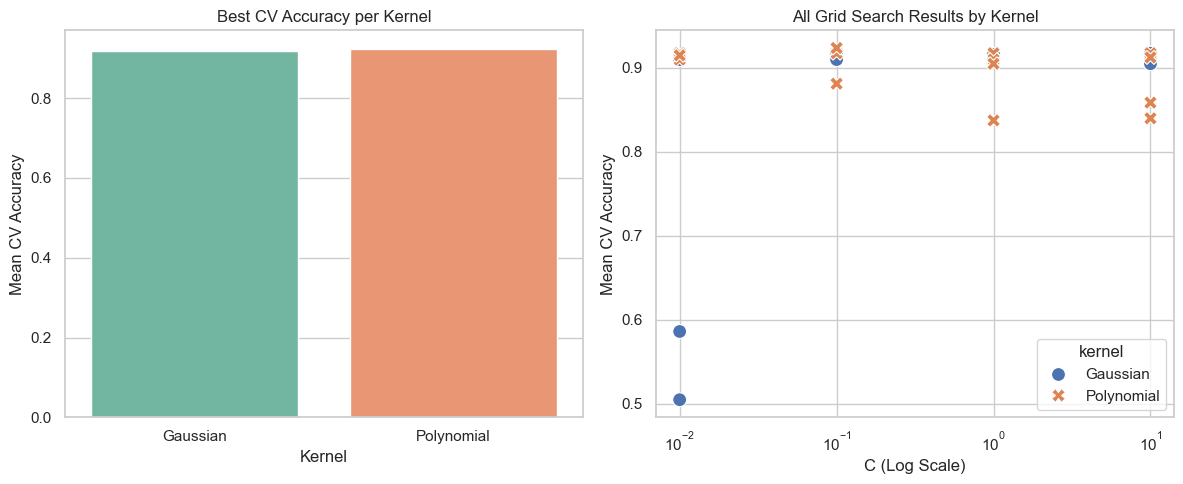

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumiamo che all_results sia una lista di dizionari (ritornata da grid_search_cv)
results_df = pd.DataFrame(all_results)

# Imposta stile dei grafici
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Confronto generale tra kernel (miglior accuracy media per ciascun kernel)
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot di tutti i risultati per confronto visivo
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


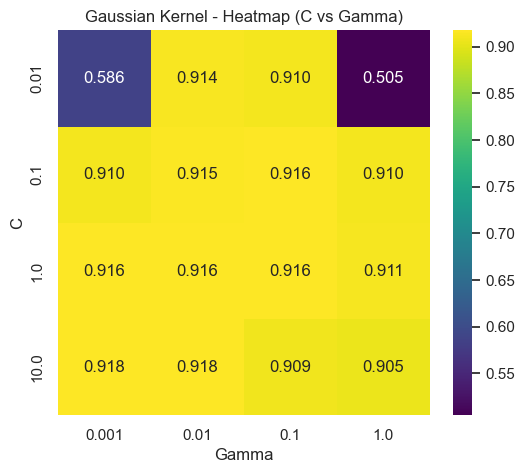

In [52]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


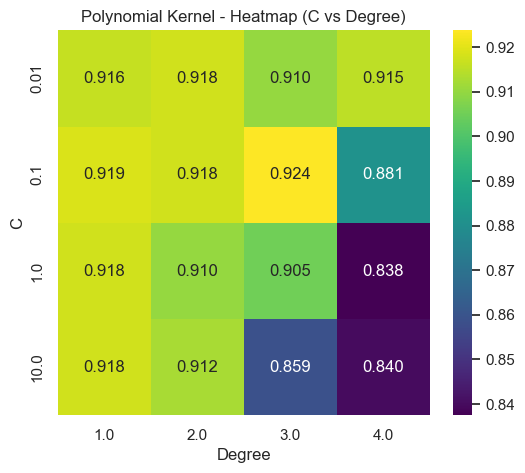

In [53]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [54]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


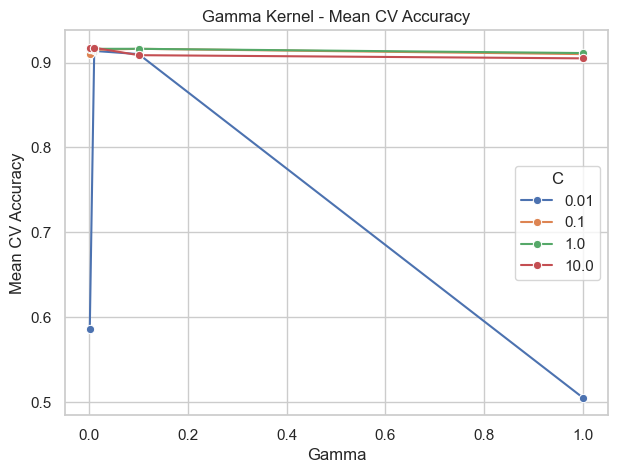

In [55]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

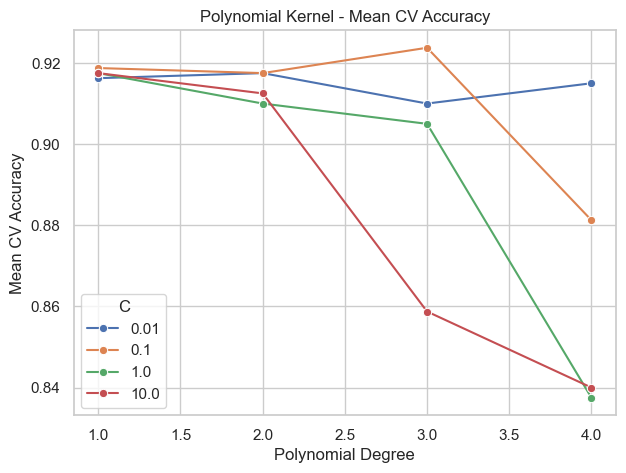

In [56]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


New grid_search that is more precise on the parameters that resulted to be better for the SVM

In [77]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C = [0.05, 0.1, 0.2, 0.5, 1, 2, 5]
gamma_grid = [0.005, 0.01, 0.02, 0.05, 0.1]
degree_grid = [2, 3, 5, 10]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid=C,  
    gamma_grid=gamma_grid,
    degree_grid=degree_grid,
    k=5
)


print("Best:", best_params, "score:", best_score)

# 3) final fit su tutto il dataset con iperparametri scelti
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit(X_train, y_train)

# 4) test su nuovi dati
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)





     pcost       dcost       gap    pres   dres
 0: -8.4266e+01 -7.0267e+01  5e+03  6e+01  3e-15
 1: -9.9279e+00 -6.8215e+01  1e+02  8e-01  2e-15
 2: -8.5834e+00 -2.6363e+01  2e+01  2e-16  5e-16
 3: -9.9610e+00 -1.2406e+01  2e+00  2e-16  5e-16
 4: -1.0420e+01 -1.1595e+01  1e+00  3e-16  4e-16
 5: -1.0614e+01 -1.1295e+01  7e-01  5e-16  3e-16
 6: -1.0707e+01 -1.1159e+01  5e-01  9e-16  3e-16
 7: -1.0799e+01 -1.1021e+01  2e-01  2e-16  3e-16
 8: -1.0856e+01 -1.0940e+01  8e-02  1e-15  4e-16
 9: -1.0882e+01 -1.0904e+01  2e-02  8e-16  4e-16
10: -1.0889e+01 -1.0896e+01  7e-03  6e-16  4e-16
11: -1.0892e+01 -1.0892e+01  6e-04  5e-16  4e-16
12: -1.0892e+01 -1.0892e+01  5e-05  2e-16  4e-16
13: -1.0892e+01 -1.0892e+01  9e-07  2e-16  5e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -9.7259e+01 -7.2380e+01  5e+03  6e+01  3e-15
 1: -1.0832e+01 -7.0380e+01  1e+02  1e+00  2e-15
 2: -9.1018e+00 -2.9914e+01  2e+01  2e-16  5e-16
 3: -1.0528e+01 -1.3299e+01  3e+00  2e-16  5e-1

c:\Users\User\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


     pcost       dcost       gap    pres   dres
 0: -1.4401e-06 -3.2000e+01  1e+03  3e+01  5e-06
 1: -1.4146e-06 -2.9055e+01  4e+01  3e-01  3e-06
 2:  5.8161e-08 -1.1187e+00  1e+00  3e-03  4e-06
 3:  1.0361e-07 -1.8885e-02  2e-02  5e-05  5e-06
 4: -4.8507e-07 -3.9599e-03  4e-03  9e-06  3e-06
 5:  1.0018e-07 -1.1465e-03  1e-03  2e-06  2e-06
 6: -2.1852e-07 -2.0199e-04  2e-04  4e-07  5e-06
 7: -3.1422e-09 -9.1212e-05  1e-04  2e-07  2e-06
 8:  5.5161e-10 -2.8789e-05  3e-05  4e-08  1e-06
 9: -2.5738e-08 -9.2176e-06  1e-05  1e-08  8e-07
10: -4.2145e-08 -3.6680e-06  4e-06  3e-09  5e-07
11: -6.8228e-08 -1.2306e-06  1e-06  9e-10  3e-07
12: -7.9648e-08 -5.9740e-07  6e-07  4e-10  2e-07
13: -8.3454e-08 -3.1009e-07  3e-07  1e-10  2e-07
14: -8.6180e-08 -1.8353e-07  1e-07  4e-11  2e-07
15: -8.6635e-08 -1.4368e-07  7e-08  2e-11  7e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -5.3347e-07 -3.2000e+01  1e+03  3e+01  2e-06
 1: -5.2402e-07 -2.9055e+01  4e+01  3e-01  1e-0

c:\Users\User\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 2:  2.1677e-08 -1.1175e+00  1e+00  3e-03  1e-06
 3:  4.7985e-08 -1.4413e-02  2e-02  4e-05  2e-06
 4: -2.1413e-07 -1.5539e-03  2e-03  4e-06  2e-06
 5: -1.7781e-07 -3.2513e-04  3e-04  7e-07  2e-06
 6: -1.0410e-07 -1.1820e-04  1e-04  2e-07  1e-06
 7: -9.7136e-08 -2.8466e-05  3e-05  5e-08  1e-06
 8: -5.8311e-08 -9.3997e-06  1e-05  1e-08  4e-07
 9: -4.1930e-08 -3.7242e-06  4e-06  5e-09  4e-07
10: -2.7577e-08 -2.4437e-06  3e-06  3e-09  4e-07
11: -4.4831e-08 -5.8975e-07  6e-07  5e-10  3e-07
12: -4.9908e-08 -2.9965e-07  3e-07  2e-10  9e-08
13: -5.4058e-08 -1.5493e-07  1e-07  7e-11  9e-08
14: -5.6690e-08 -8.7868e-08  4e-08  2e-11  4e-08
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -1.2180e-06 -3.2000e+01  1e+03  3e+01  5e-06
 1: -1.1964e-06 -2.9055e+01  4e+01  3e-01  4e-06
 2:  4.9320e-08 -1.1176e+00  1e+00  3e-03  1e-05
 3:  9.2882e-08 -1.4714e-02  2e-02  4e-05  1e-05


...

     pcost       dcost       gap    pres   dres
 0:  2.9305e-05 -3.2000e+03  8e+03  3e-01  2e-05
 1:  4.2213e-05 -1.2106e+02  2e+02  3e-03  2e-05
 2:  4.2710e-05 -1.2246e+00  2e+00  3e-05  3e-05
 3:  3.8440e-05 -2.4173e-02  3e-02  6e-07  3e-05
 4:  1.3396e-05 -3.6316e-03  5e-03  8e-08  2e-05
 5:  4.1757e-06 -6.9898e-04  9e-04  1e-08  2e-05
 6:  1.4441e-06 -1.3550e-04  2e-04  2e-09  5e-06
 7:  5.3263e-07 -3.9398e-05  5e-05  5e-10  3e-06
 8:  2.7486e-07 -1.3424e-05  2e-05  1e-10  2e-06
 9:  6.9637e-08 -4.3101e-06  5e-06  4e-11  1e-06
10: -2.7698e-08 -1.2300e-06  1e-06  9e-12  5e-07
11: -5.4610e-08 -5.5768e-07  6e-07  3e-12  3e-07
12: -6.5406e-08 -2.7256e-07  2e-07  1e-12  2e-07
13: -6.8990e-08 -1.9940e-07  2e-07  5e-13  7e-08
14: -7.0795e-08 -1.5044e-07  9e-08  3e-13  1e-07
15: -7.2734e-08 -1.1620e-07  5e-08  1e-13  5e-08
Optimal solution found.


c:\Users\User\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


     pcost       dcost       gap    pres   dres
 0:  3.6589e-05 -3.2000e+03  8e+03  3e-01  2e-05
 1:  5.2705e-05 -1.2107e+02  2e+02  3e-03  2e-05
 2:  5.3303e-05 -1.2261e+00  2e+00  3e-05  2e-05
 3:  4.6213e-05 -2.6107e-02  3e-02  6e-07  2e-05
 4:  1.3270e-05 -3.3547e-03  4e-03  7e-08  1e-05
 5:  5.5041e-06 -8.6020e-04  1e-03  1e-08  1e-05
 6:  2.1405e-06 -2.2622e-04  3e-04  3e-09  5e-06
 7:  8.6521e-07 -6.2781e-05  8e-05  6e-10  7e-06
 8:  3.1338e-07 -1.7302e-05  2e-05  2e-10  3e-06
 9:  1.8299e-07 -8.2488e-06  1e-05  6e-11  9e-07
10:  8.5239e-08 -3.1585e-06  4e-06  2e-11  8e-07
11:  1.7511e-08 -1.2486e-06  1e-06  6e-12  3e-07
12: -1.9604e-08 -4.9299e-07  6e-07  2e-12  2e-07
13: -3.4441e-08 -2.0595e-07  2e-07  5e-13  7e-08
14: -3.8683e-08 -1.3642e-07  1e-07  2e-13  5e-08
15: -4.0990e-08 -1.0116e-07  7e-08  1e-13  6e-08
Optimal solution found.
{'C': 0.1, 'degree': 3, 'kernel': 'Polynomial'} 0.9237499999999998
Best: {'C': 0.1, 'degree': 3, 'kernel': 'Polynomial'} score: 0.92374999999999

c:\Users\User\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\User\anaconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


 2: -1.0130e+01 -6.1801e+01  7e+01  1e-01  2e-11
 3: -9.9012e+00 -2.5789e+01  2e+01  3e-02  6e-12
 4: -1.0129e+01 -1.6927e+01  8e+00  8e-03  4e-12
 5: -1.0414e+01 -1.3229e+01  3e+00  3e-03  4e-12
 6: -1.0585e+01 -1.1817e+01  1e+00  1e-03  3e-12
 7: -1.0636e+01 -1.1544e+01  1e+00  7e-04  3e-12
 8: -1.0666e+01 -1.1361e+01  7e-01  4e-04  3e-12
 9: -1.0735e+01 -1.1041e+01  3e-01  1e-04  4e-12
10: -1.0740e+01 -1.0945e+01  2e-01  5e-05  3e-12
11: -1.0784e+01 -1.0830e+01  5e-02  9e-06  4e-12
12: -1.0795e+01 -1.0803e+01  7e-03  3e-07  4e-12
13: -1.0798e+01 -1.0799e+01  9e-04  4e-08  4e-12
14: -1.0798e+01 -1.0798e+01  2e-05  6e-10  4e-12
15: -1.0798e+01 -1.0798e+01  4e-07  9e-12  4e-12
Optimal solution found.


In [78]:
print(classification_report(y_train, X_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       404
           1       0.94      0.95      0.95       396

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [79]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.92      0.90        96
           1       0.92      0.89      0.91       104

    accuracy                           0.91       200
   macro avg       0.90      0.91      0.90       200
weighted avg       0.91      0.91      0.91       200



C:\Users\User\AppData\Local\Temp\ipykernel_17972\1660918594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


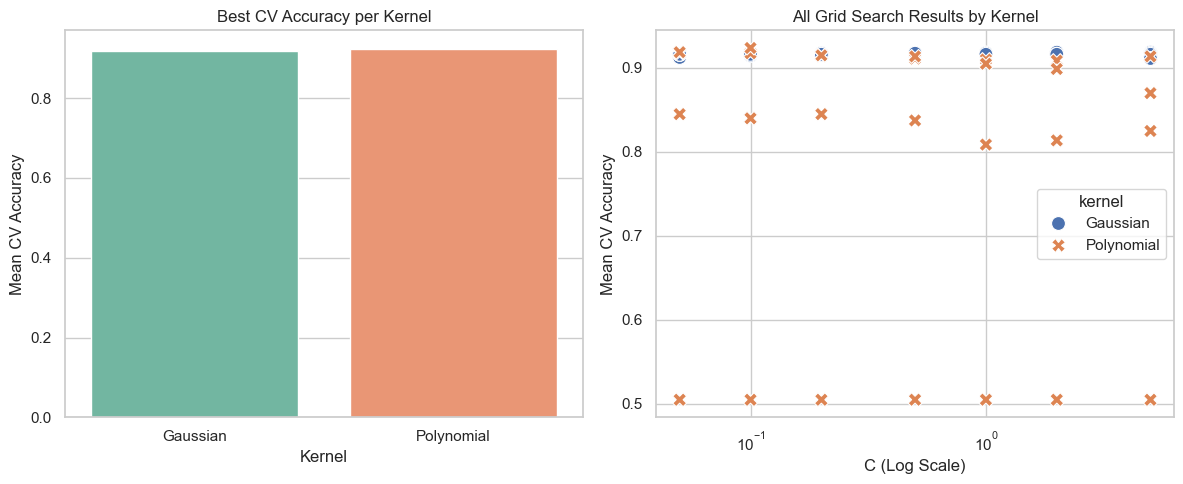

In [80]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumiamo che all_results sia una lista di dizionari (ritornata da grid_search_cv)
results_df = pd.DataFrame(all_results)

# Imposta stile dei grafici
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Confronto generale tra kernel (miglior accuracy media per ciascun kernel)
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot di tutti i risultati per confronto visivo
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


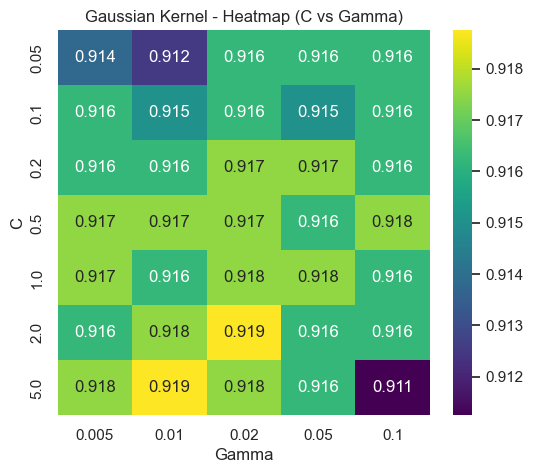

In [82]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


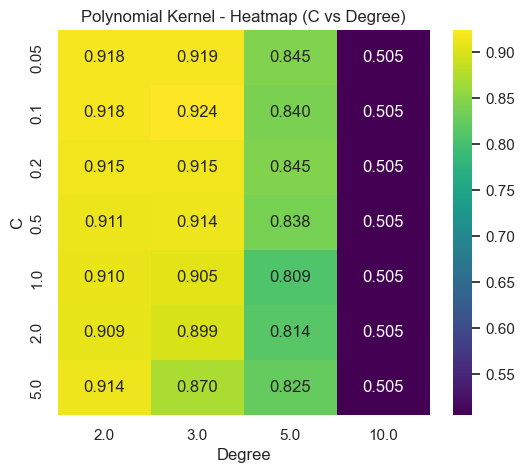

In [83]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [84]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


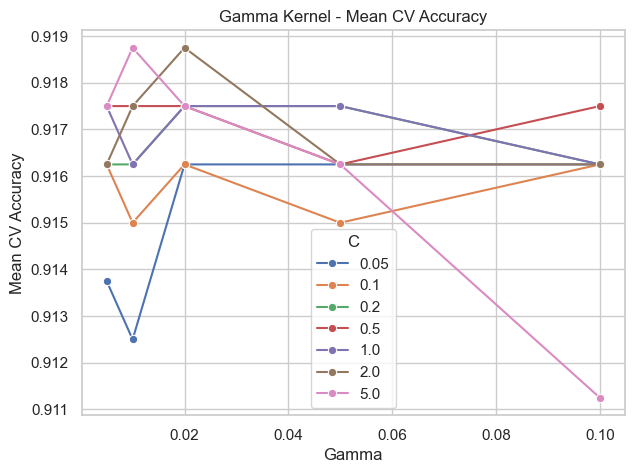

In [85]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

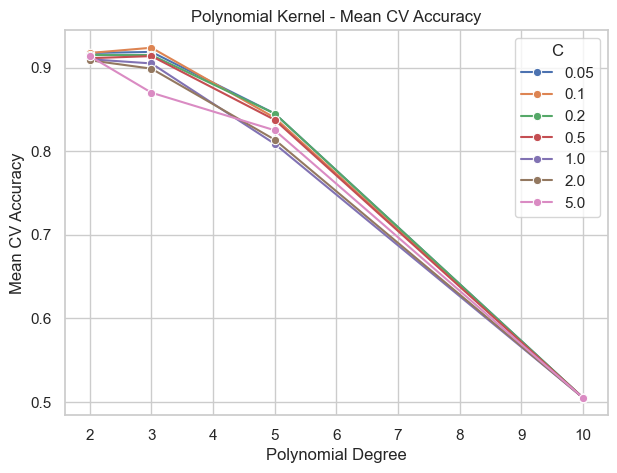

In [86]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()


# Part 2

In [57]:
# Split features and target
X = df.drop("gt", axis=1).values
y = df["gt"].values.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) grid search 
C_grid = [0.01, 0.1, 1, 10]
gamma_grid = [0.001, 0.01, 0.1, 1]
degree_grid = [1 ,2, 3, 4]

best_params, best_score, all_results = grid_search_cv(
    X_train, y_train,
    C_grid, gamma_grid=gamma_grid, degree_grid=degree_grid, k=5, smo=True
)


print("Best:", best_params, "score:", best_score)

# 3) final fit su tutto il dataset con iperparametri scelti
if best_params['kernel'] == 'Polynomial':
    model = SVM(C=best_params['C'], kernel='Polynomial', p=best_params['degree'])
else:
    model = SVM(C=best_params['C'], kernel=best_params['kernel'], gamma=best_params['gamma'])

model.fit_smo(X_train, y_train)

# 4) test su nuovi dati
y_pred = model.predict(X_test)
X_pred = model.predict(X_train)


--- Iteration 1, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 36

--- Iteration 2, consecutive passes without updates: 0 ---
Number of alphas updated in this iteration: 0

--- Iteration 3, consecutive passes without updates: 1 ---
Number of alphas updated in this iteration: 0

--- Iteration 4, consecutive passes without updates: 2 ---
Number of alphas updated in this iteration: 0

--- Iteration 5, consecutive passes without updates: 3 ---
Number of alphas updated in this iteration: 0

--- Iteration 6, consecutive passes without updates: 4 ---
Number of alphas updated in this iteration: 0

--- Iteration 7, consecutive passes without updates: 5 ---
Number of alphas updated in this iteration: 0

--- Iteration 8, consecutive passes without updates: 6 ---
Number of alphas updated in this iteration: 0

--- Iteration 9, consecutive passes without updates: 7 ---
Number of alphas updated in this iteration: 0

--- Iteration 10, consecutive passes without

C:\Users\User\AppData\Local\Temp\ipykernel_17972\1660918594.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")


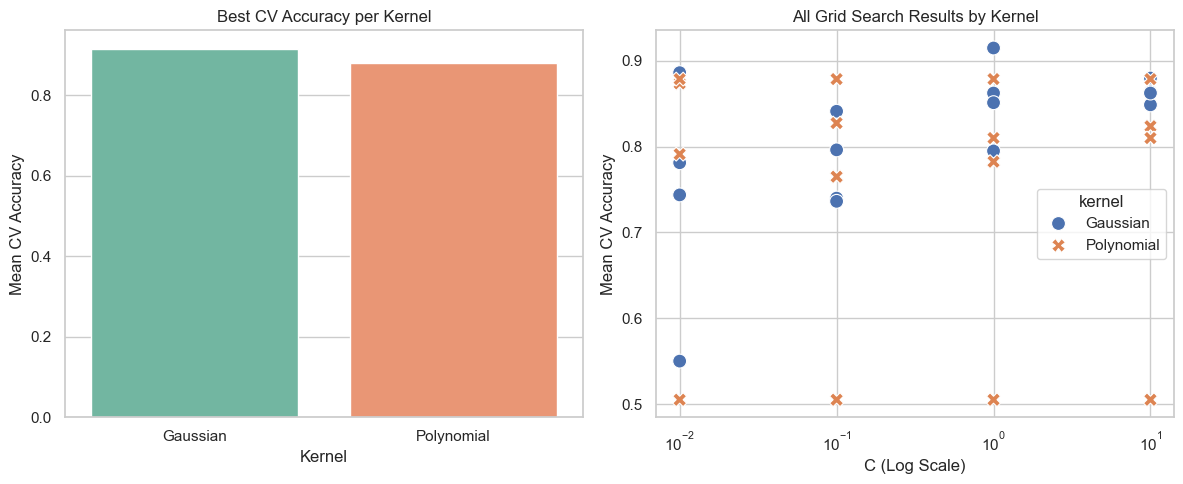

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assumiamo che all_results sia una lista di dizionari (ritornata da grid_search_cv)
results_df = pd.DataFrame(all_results)

# Imposta stile dei grafici
sns.set(style="whitegrid")
plt.figure(figsize=(12, 5))

# 1. Confronto generale tra kernel (miglior accuracy media per ciascun kernel)
plt.subplot(1, 2, 1)
best_scores = results_df.groupby("kernel")["mean_score"].max().reset_index()
sns.barplot(data=best_scores, x="kernel", y="mean_score", palette="Set2")
plt.title("Best CV Accuracy per Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("Kernel")

# 2. Line plot di tutti i risultati per confronto visivo
plt.subplot(1, 2, 2)
sns.scatterplot(data=results_df, x="C", y="mean_score", hue="kernel", style="kernel", s=100)
plt.title("All Grid Search Results by Kernel")
plt.ylabel("Mean CV Accuracy")
plt.xlabel("C (Log Scale)")
plt.xscale("log")

plt.tight_layout()
plt.show()


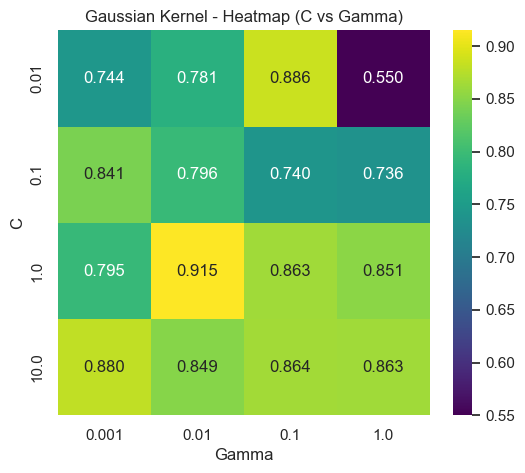

In [59]:
gaussian_df = results_df[results_df['kernel'] == 'Gaussian']
if not gaussian_df.empty:
    pivot_table = gaussian_df.pivot(index='C', columns='gamma', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Gaussian Kernel - Heatmap (C vs Gamma)")
    plt.xlabel("Gamma")
    plt.ylabel("C")
    plt.show()


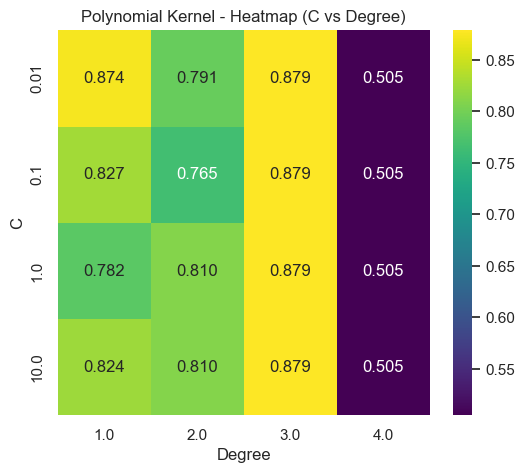

In [60]:
poly_df = results_df[results_df['kernel'] == 'Polynomial']
if not poly_df.empty:
    pivot_table = poly_df.pivot(index='C', columns='degree', values='mean_score')
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
    plt.title("Polynomial Kernel - Heatmap (C vs Degree)")
    plt.xlabel("Degree")
    plt.ylabel("C")
    plt.show()

In [61]:
poly_df['C'] = poly_df['C'].astype(str)
gaussian_df['C'] = gaussian_df['C'].astype(str)

C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  poly_df['C'] = poly_df['C'].astype(str)
C:\Users\User\AppData\Local\Temp\ipykernel_17972\3821612633.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gaussian_df['C'] = gaussian_df['C'].astype(str)


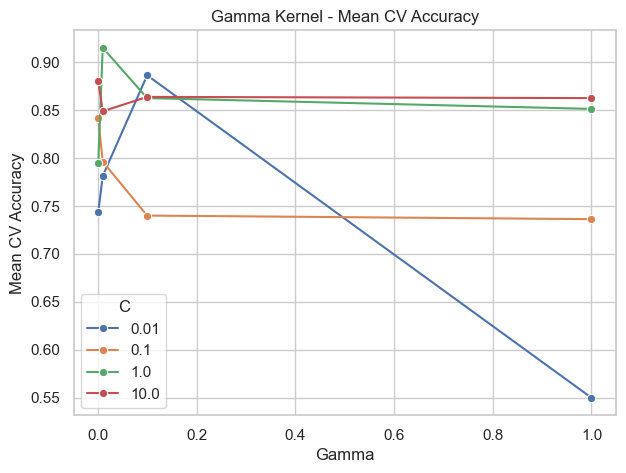

In [62]:
if not gaussian_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=gaussian_df, x='gamma', y='mean_score', hue='C', marker='o')
    plt.title("Gamma Kernel - Mean CV Accuracy")
    plt.xlabel("Gamma")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()

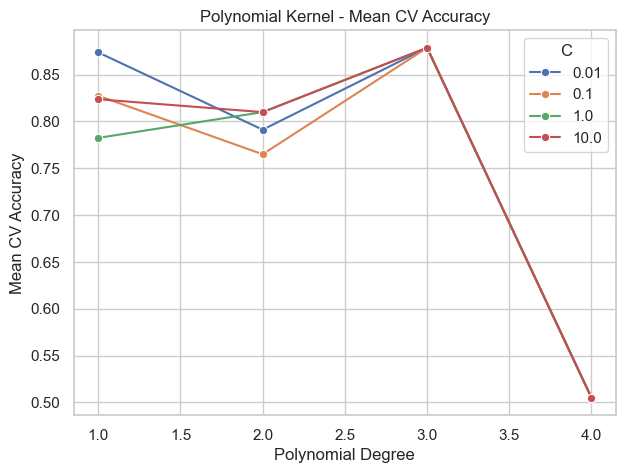

In [63]:
if not poly_df.empty:
    plt.figure(figsize=(7, 5))
    sns.lineplot(data=poly_df, x='degree', y='mean_score', hue='C', marker='o')
    plt.title("Polynomial Kernel - Mean CV Accuracy")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Mean CV Accuracy")
    plt.legend(title="C")
    plt.show()
